# Trading the 3-month micro butterfly off the **aggregate** long-end ETF ladder

> *"execute the micro fly strategy based on the 3m risk bucket using the etf risk buckets in
> aggregate (all ETFs with 1bn or more in cash treasuries space) rather than just a single etf
> holding. lets just focus on long term."*

The single-fund version of this trade is dead, and dead for measured reasons
(`RESULTS.md`). The question here is narrower and answerable: **does aggregating the ladder
across every long-end Treasury ETF change the answer?**

That question has exactly one honest form. Not "what Sharpe does the aggregate print" — with
enough configurations something always prints a good one — but **the aggregate against the
single fund, through one pipeline, on one date axis, with one cost model, cell by matched
cell.** Everything below is arranged around that comparison.

---

## What data actually exists, before anything is claimed

This is the first thing to settle, because the answer constrains the whole study.

| fund | AUM | route | cadence | history | publication lag |
|---|---|---|---|---|---|
| **TLT** | $46.9bn | iShares dated endpoint | daily | 2016-01-04 → | overnight |
| **GOVT** | $44.1bn | iShares dated endpoint | daily | 2018-01-02 → | overnight |
| **SPTL** | $10.8bn | **SEC Form N-PORT** | **quarterly** | 2019-09-30 → | **53–62 days** |
| **VGLT** | $10.4bn | **SEC Form N-PORT** | **quarterly** | 2019-11-30 → | **53–62 days** |

SSGA serves one workbook — whatever is current — and Vanguard serves one month-end and
**silently ignores** a date parameter (HTTP 200, different date in the body). Neither can be
backfilled. Their only history is N-PORT, which is quarterly and will stay quarterly: the SEC
delayed public monthly N-PORT to **2027-11-17** and in February 2026 proposed scaling the
amendments back further.

So there is **no daily multi-issuer panel and there cannot be one.** What exists is a
*staircase*: TLT and GOVT update every day, SPTL and VGLT step eight times a year, and every
row is gated on `available_from` — the date the filing became public — never on the date it
describes. Keying on the as-of date would hand those two funds a two-month view of the future,
which is roughly a hundred times any edge being chased here.

**The window that carries real multi-issuer data is 2020-01-29 onward.** Before that the
"aggregate" is TLT wearing an aggregate's name. Everything in the headline comparison starts
there, for *every* fund set including TLT-only, so the z-scores are standardised against the
same amount of history.

---

## The design problem: you cannot add active weights

TLT tracks ICE US Treasury 20+. SPTL and VGLT track Bloomberg **10+** indices. Their active
weights are shares of different boards — a 40-bond board and a ~100-bond board — so `w_f − w_i`
for the same CUSIP means two different things. Both columns are in [0, 1], both sum to 1, and
adding them produces a plausible number with no denominator. No shape, dtype or range check
can see it; `aggregate.assert_common_benchmark` compares the benchmark vectors themselves and
raises, and there is a mutation-checked test for it.

Two constructions avoid the trap, and both are built:

**(a) Ownership.** Par held by every fund ÷ the bond's publicly held (ex-SOMA) amount
outstanding. Dollars over dollars — denominator-consistent by construction, independent of any
fund's index band.

**(b) Active weight against ONE common 20y+ benchmark.** Every fund restricted to the same
20y+ slice, renormalised inside it, measured against one float-weighted benchmark. What that
renormalisation discards — each fund's view on *how much* long end to hold — is reported in §4
rather than dropped.

In [1]:
%matplotlib inline
import os, sys, json, time, warnings
os.environ.setdefault("ARBS_SUPABASE_ENABLED", "0")
os.environ.setdefault("ARBS_ETF_HOLDINGS_DIR",
                      "C:/Users/chris/clee/ARBS/MDP/ETFHoldings/etf_holdings_cache")
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from RVUtils.ETFRebalance import aggregate as AG
from RVUtils.ETFRebalance import bond_panel as BP
from RVUtils.ETFRebalance import costs as C
from RVUtils.ETFRebalance import engine as EN
from RVUtils.ETFRebalance import float_panel as FP
from RVUtils.ETFRebalance import grid as GR
from RVUtils.ETFRebalance import ic as IC
from RVUtils.ETFRebalance import signals as SIG
import figstyle as FS
FS.use()

pd.set_option("display.width", 200); pd.set_option("display.max_columns", 40)
DATA = os.path.join(os.getcwd(), "_data")

---

## 1. The `CONFIG`

One dict describes the whole study. `fund_sets` is the axis the headline turns on;
everything else is held identical across it so the comparison is about the fund set and
nothing else.

In [2]:
CONFIG = {
    # WHICH FUNDS ------------------------------------------------------------------
    # tlt_only        the single-fund control
    # coupon_long     the user's cut: every >=$1bn coupon-UST ETF reaching 20y+
    # coupon_long_govt  + GOVT's 20y+ sleeve (a 1y+ fund, so a sleeve of a bigger book)
    # daily_only      the aggregate you could have traded DAILY over the whole sample
    "fund_sets": ("tlt_only", "coupon_long", "coupon_long_govt", "daily_only"),

    # THE LADDER -------------------------------------------------------------------
    "band": (20.0, 31.0),      # the common slice both constructions are measured on
    "widths": (0.25, 0.5, 1.0),  # 3-month is the ask; 6m and 12m are the controls
    "combines": ("book", "equal"),   # dollar-weighted vs one-fund-one-vote
    "lookback": 250,           # trailing window for the bucket's own-history z
    "min_periods": 120,        # STATED minimum history -- no z on a handful of days
    "weight_basis": "dv01",    # share of RISK, not of money

    # THE TRADE --------------------------------------------------------------------
    "hold_days": (5, 10, 21, 42),
    "thresholds": (0.0, 1.0, 1.5),   # |z| entry threshold, in historical-z units
    "signs": (1, -1),          # searched, never assumed -- see the note below
    "exec_lag": (1, 2, 5),     # >= 1 ALWAYS. Never 0, in any cell.
    "wing_gap_max_y": (0.5, 0.8, 1.5),   # how far the wings may sit from the belly
    "start": "2016-01-01",     # panel start; the LADDER start is measured, not chosen
}

# NOT swept, and stated rather than omitted: a z-based EXIT. The engine's exit is
# time-based (`hold_days`), and the marking loop it lives inside carries four structural
# rules its docstring catalogues -- complete-case marks per leg, the full round trip
# charged once at the exit, nancumsum on carry, no overlapping positions in the same
# belly -- each of which was a measured defect before it was a rule. Re-implementing that
# loop to add a signal-driven exit risks reintroducing them for an axis that is second
# order to entry threshold and holding horizon, both of which ARE swept. The omission is
# a choice with a reason, not an oversight.

# Why `signs` is searched. An unusually heavy bucket has two opposite readings -- scarcity
# says the bonds are rich, "the manager has already bought" says the flow is spent -- and
# the parent study measured the raw active-weight relationship running BACKWARDS. Asserting
# a sign would be assuming the answer; both directions are run and both are counted in the
# trial total the deflated Sharpe is computed against.
CONFIG

{'fund_sets': ('tlt_only', 'coupon_long', 'coupon_long_govt', 'daily_only'),
 'band': (20.0, 31.0),
 'widths': (0.25, 0.5, 1.0),
 'combines': ('book', 'equal'),
 'lookback': 250,
 'min_periods': 120,
 'weight_basis': 'dv01',
 'hold_days': (5, 10, 21, 42),
 'thresholds': (0.0, 1.0, 1.5),
 'signs': (1, -1),
 'exec_lag': (1, 2, 5),
 'wing_gap_max_y': (0.5, 0.8, 1.5),
 'start': '2016-01-01'}

---

## 2. The universe and the ladders

`prepare_universe` gates, benchmarks and residualises the 20y+ board once. Every aggregate
column is then attached to that one frame, which is why this notebook uses
`aggregate.run_overlays` rather than `grid.run_grid` — the latter rebuilds the universe per
cache key and would silently discard every attached column.

In [3]:
t0 = time.time()
panel = FP.asof_join(BP.load(), FP.load())
uni, funnel = EN.prepare_universe(EN.merge_config({
    "fund": "TLT",
    "universe": {"start": CONFIG["start"], "ttm_min": CONFIG["band"][0],
                 "ttm_max": CONFIG["band"][1]},
}), panel=panel)
# prepare_universe's start filter trims only the BENCHMARK side; the holdings outer-join
# drags the fund's full history back in, so filter explicitly.
uni = uni[uni["date"] >= pd.Timestamp(CONFIG["start"])].reset_index(drop=True)
print(f"universe {len(uni):,} bond-days | {uni['date'].nunique():,} dates | "
      f"{uni['cusip'].nunique()} cusips | {uni['date'].min().date()}..{uni['date'].max().date()}")
print(f"median eligible bonds per date: {uni.groupby('date')['cusip'].nunique().median():.0f}")

built = AG.build_ladders(uni, fund_sets=CONFIG["fund_sets"], widths=CONFIG["widths"],
                         combines=CONFIG["combines"], band=CONFIG["band"],
                         lookback=CONFIG["lookback"], min_periods=CONFIG["min_periods"],
                         weight_basis=CONFIG["weight_basis"], verbose=True)
LADDER_START = built["ladder_start"]
U = AG.attach_many(uni, built["specs"], band=CONFIG["band"])
U = U[U["date"] >= LADDER_START].reset_index(drop=True)
print(f"\n{len(built['specs'])} signal columns | ladder start {LADDER_START.date()} | "
      f"{U['date'].nunique():,} tradeable dates | {time.time()-t0:.0f}s")

universe 80,953 bond-days | 2,528 dates | 71 cusips | 2016-01-04..2026-08-19
median eligible bonds per date: 32



first date each fund set is COMPLETE:


   tlt_only             2016-01-04


   coupon_long          2020-01-29


   coupon_long_govt     2020-01-29


...


--- fund set coupon_long_govt: TLT, GOVT, SPTL, VGLT from 2020-01-29 ---


fund        source first_date  last_date  panel_dates  distinct_books  stale_days_med  stale_days_max  board_share_med  board_share_min  par_bn_med
GOVT ishares_daily 2018-01-02 2026-08-19         2155            2155             0.0               0         0.812500         0.333333    3.200699
SPTL         nport 2019-11-27 2026-08-19         1676              27           105.0             152         0.971429         0.500000    4.030318
 TLT ishares_daily 2016-01-04 2026-08-19         2528            2528             0.0               0         1.000000         1.000000   15.002285
VGLT         nport 2020-01-29 2026-08-19         1622              27           104.0             154         0.967742         0.333333    5.810874



--- fund set daily_only: TLT, GOVT from 2020-01-29 ---


fund        source first_date  last_date  panel_dates  distinct_books  stale_days_med  stale_days_max  board_share_med  board_share_min  par_bn_med
GOVT ishares_daily 2018-01-02 2026-08-19         2155            2155             0.0               0           0.8125         0.333333    3.200699
 TLT ishares_daily 2016-01-04 2026-08-19         2528            2528             0.0               0           1.0000         1.000000   15.002285



39 signal columns | ladder start 2020-01-29 | 1,638 tradeable dates | 17s


### 2b. How many bonds is a "3-month bucket", really?

This is the structural fact that decides what the ask can even mean at the long end, and it
is not a property of the code. The Treasury issues roughly four bonds a year into a ten-year
window, so a 20y+ board carries about 40 names spread over 40 quarterly buckets.

In [4]:
rows = []
for w in CONFIG["widths"]:
    b = AG.bucket_of(uni["ttm"], band_low=CONFIG["band"][0], band_high=CONFIG["band"][1],
                     width_y=w)
    n = uni.groupby([uni["date"], b])["cusip"].nunique()
    rows.append({"width_y": w, "bonds_per_bucket_med": n.median(), "mean": round(n.mean(), 3),
                 "p90": n.quantile(.9), "max": int(n.max()),
                 "occupied_buckets_med": uni.assign(_b=b).groupby("date")["_b"].nunique().median()})
occ = pd.DataFrame(rows)
display(occ)
print("A 0.25y bucket at 20y+ holds a MEDIAN OF ONE BOND. At the long end a 3-month bucket\n"
      "ladder is therefore a per-CUSIP signal wearing a bucket's clothes -- the substitution\n"
      "noise that bucketing removes at the front end is not there to remove. Only at 0.5y\n"
      "(median 2) and 1.0y (median 4) does the aggregation do anything at all, which is why\n"
      "width is swept rather than fixed at the 3 months the request named.")

,width_y,bonds_per_bucket_med,mean,p90,max,occupied_buckets_med
0,0.25,1.0,1.005,1.0,2,32.0
1,0.50,2.0,1.729,2.0,3,19.0
2,1.00,4.0,3.281,4.0,5,10.0


A 0.25y bucket at 20y+ holds a MEDIAN OF ONE BOND. At the long end a 3-month bucket
ladder is therefore a per-CUSIP signal wearing a bucket's clothes -- the substitution
noise that bucketing removes at the front end is not there to remove. Only at 0.5y
(median 2) and 1.0y (median 4) does the aggregation do anything at all, which is why
width is swept rather than fixed at the 3 months the request named.


---

## 3. Coverage and staleness — what the "aggregate" is made of

Computed over days a book exists, never over all panel dates. That distinction is not
pedantic: it is how the parent study's 127-day 2017 hole in TLT read as *"held nothing"*
rather than *"no file"*.

In [5]:
cov = pd.concat([v.assign(fund_set=k) for k, v in built["coverage"].items()], ignore_index=True)
display(cov[cov["fund_set"] == "coupon_long_govt"]
        [["fund", "source", "first_date", "last_date", "distinct_books",
          "stale_days_med", "stale_days_max", "board_share_med", "board_share_min",
          "par_bn_med"]].round(3))
print("distinct_books is the honest cadence number: TLT and GOVT have thousands, SPTL and\n"
      "VGLT have 27 each. stale_days_med ~105 says the median day's 'aggregate' contains a\n"
      "three-and-a-half-month-old photograph of two of its four funds.")

,fund,source,first_date,last_date,distinct_books,stale_days_med,stale_days_max,board_share_med,board_share_min,par_bn_med
4,GOVT,ishares_daily,2018-01-02,2026-08-19,2155,0.0,0,0.812,0.333,3.201
5,SPTL,nport,2019-11-27,2026-08-19,27,105.0,152,0.971,0.500,4.030
6,TLT,ishares_daily,2016-01-04,2026-08-19,2528,0.0,0,1.000,1.000,15.002
7,VGLT,nport,2020-01-29,2026-08-19,27,104.0,154,0.968,0.333,5.811


distinct_books is the honest cadence number: TLT and GOVT have thousands, SPTL and
VGLT have 27 each. stale_days_med ~105 says the median day's 'aggregate' contains a
three-and-a-half-month-old photograph of two of its four funds.


### 4. What construction (b) renormalises away

Restricting every fund to a common 20y+ slice is what makes the denominators match. It also
deletes each fund's view on **how much** long end to hold at all — and that quantity cannot be
measured on a common board, because TLT's board has no 10–20y half to be light in. So it is
reported.

In [6]:
key = AG.column_name("act", "coupon_long_govt", 0.25, "book")
off = built["offslice"][key]
off = off[off["date"] >= LADDER_START]
display(off.groupby("ticker").agg(
    inslice_share_par_med=("inslice_share_par", "median"),
    offslice_share_par_med=("offslice_share_par", "median"),
    n_inslice_med=("n_inslice", "median"),
    stale_days_med=("stale_days", "median")).round(4))
print("TLT keeps 99% of its par inside the slice -- it IS a 20y+ fund. SPTL and VGLT keep\n"
      "~55%: nearly half of each book is the 10-20y half of a Bloomberg long index, and the\n"
      "common-slice construction cannot see it. GOVT keeps ~16%. The prior ladder work in\n"
      "this repo flagged a residual of 7.7% as material; this is six times that.")

,inslice_share_par_med,offslice_share_par_med,n_inslice_med,stale_days_med
ticker,,,,
GOVT,0.1572,0.8428,28.0,0.0
SPTL,0.5537,0.4463,34.0,105.0
TLT,0.9914,0.0086,35.0,0.0
VGLT,0.5611,0.4389,33.0,105.0


TLT keeps 99% of its par inside the slice -- it IS a 20y+ fund. SPTL and VGLT keep
~55%: nearly half of each book is the 10-20y half of a Bloomberg long index, and the
common-slice construction cannot see it. GOVT keeps ~16%. The prior ladder work in
this repo flagged a residual of 7.7% as material; this is six times that.


---

## 5. **The measurement that decides the question**

Before any P&L: is the aggregate ladder a *different signal* from TLT's? If the two correlate
at 0.99 then every downstream difference is noise, and a grid with a thousand cells will
still hand back a winner.

fund_set         coupon_long  coupon_long_govt  daily_only
measure width_y                                           
level   0.25          0.9937            0.9703      0.9707
        0.50          0.9941            0.9716      0.9705
        1.00          0.9948            0.9865      0.9849
z       0.25          0.9917            0.9208      0.9242
        0.50          0.9837            0.8819      0.8853
        1.00          0.9915            0.9309      0.9378

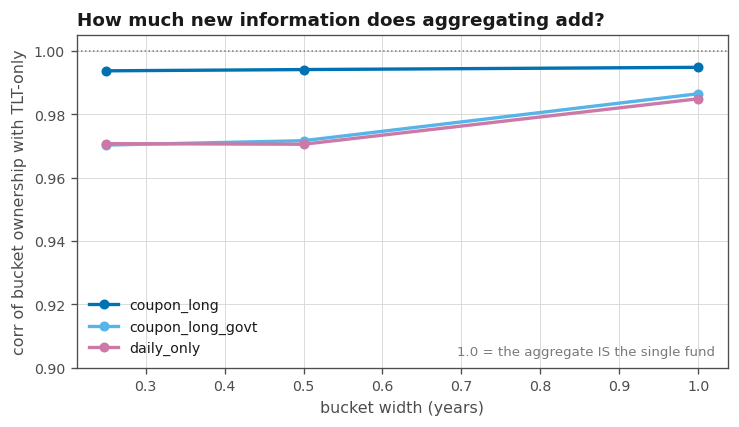

In [7]:
rows = []
for cons, col in (("own", "own"), ("own_z", "own_z")):
    for w in CONFIG["widths"]:
        sel = {fs: built["ladders"][AG.column_name("own", fs, w)] for fs in CONFIG["fund_sets"]}
        c = AG.independence(sel, col)
        for fs in CONFIG["fund_sets"]:
            if fs == "tlt_only":
                continue
            rows.append({"measure": "level" if cons == "own" else "z", "width_y": w,
                         "fund_set": fs, "corr_with_tlt_only": float(c.loc[fs, "tlt_only"])})
indep = pd.DataFrame(rows)
display(indep.pivot_table(index=["measure", "width_y"], columns="fund_set",
                          values="corr_with_tlt_only").round(4))

fig, ax = FS.panels(w=7.0, h=3.6)
for i, (fs, g) in enumerate(indep[indep["measure"] == "level"].groupby("fund_set")):
    ax.plot(g["width_y"], g["corr_with_tlt_only"], marker="o",
            color=[FS.ROLE["thesis"], FS.ROLE["thesis_alt"], FS.ROLE["verified"]][i], label=fs)
ax.axhline(1.0, color=FS.INK["muted"], lw=0.9, ls=":")
ax.set_ylim(0.90, 1.005); ax.set_xlabel("bucket width (years)")
ax.set_ylabel("corr of bucket ownership with TLT-only")
ax.set_title("How much new information does aggregating add?")
FS.annotate_null(ax, "1.0 = the aggregate IS the single fund", loc="lower right")
ax.legend(); plt.show()

### 6. The footprint uplift — and the scope caveat that has to travel with it

In [8]:
rows = []
for fs in CONFIG["fund_sets"]:
    l = built["ladders"][AG.column_name("own", fs, 0.25)]
    l = l[l["date"] >= LADDER_START]
    rows.append({"fund_set": fs, "funds": ",".join(AG.FUND_SETS[fs].tickers),
                 "own_med_pct": l["own"].median() * 100,
                 "own_p90_pct": l["own"].quantile(.9) * 100,
                 "par_bn_med": l.groupby("date")["agg_par"].sum().median() / 1e9})
foot = pd.DataFrame(rows)
foot["uplift_vs_tlt"] = foot["own_med_pct"] / foot.loc[foot.fund_set == "tlt_only",
                                                       "own_med_pct"].iloc[0]
display(foot.round(4))
print("SCOPE, stated with the number: VGLT's N-PORT book is the WHOLE multi-share-class fund,\n"
      "not the ETF share class -- measured net assets $14.599bn against $10.368bn of ETF AUM,\n"
      "a ratio of 1.408. SPTL's ratio is 0.965 (it IS the ETF). So an ownership figure that\n"
      "includes VGLT measures INDEX-FUND-FAMILY footprint, about 1.4x the ETF's. The demand is\n"
      "real and lands on the same bonds; only the label has to be right.\n\n"
      "For comparison, the Fed's SOMA holds a median ~17.8% of a long issue. The whole ETF\n"
      "complex, on the widest cut here, holds about a quarter of that.")

,fund_set,funds,own_med_pct,own_p90_pct,par_bn_med,uplift_vs_tlt
0,tlt_only,TLT,2.7890,7.8923,45.2665,1.0000
1,coupon_long,"TLT,SPTL,VGLT",3.6307,9.0962,55.1742,1.3018
2,coupon_long_govt,"TLT,GOVT,SPTL,VGLT",4.1442,9.7826,59.8620,1.4859
3,daily_only,"TLT,GOVT",3.3077,8.5843,49.9543,1.1860


SCOPE, stated with the number: VGLT's N-PORT book is the WHOLE multi-share-class fund,
not the ETF share class -- measured net assets $14.599bn against $10.368bn of ETF AUM,
a ratio of 1.408. SPTL's ratio is 0.965 (it IS the ETF). So an ownership figure that
includes VGLT measures INDEX-FUND-FAMILY footprint, about 1.4x the ETF's. The demand is
real and lands on the same bonds; only the label has to be right.

For comparison, the Fed's SOMA holds a median ~17.8% of a long issue. The whole ETF
complex, on the widest cut here, holds about a quarter of that.


---

## 7. The IC surface — with both nulls in the same table

A backtest sees one path through a large space of choices. An information coefficient asks the
prior question on two orders of magnitude more evidence and with no selection rule. The nulls
are computed on the same rows with the same standardisation, because a comparison across two
tables is not a comparison.

* `null_deletion` — the **calendar-only** signal. Reads no holdings file at all.
* `null_cross22/24/26/28` — the **matched-rarity placebo**: the same event shape, the same
  firing rate, at maturities where no index does anything.
* `agg_floattwin__board__*` — the ownership ladder's **null twin**: the same bucket
  construction on the board's own float share. Also reads no holdings file.
* `ctrl_resid` — the bond's own richness. The control, not a thesis.

In [9]:
ic_path = os.path.join(DATA, "mi_ic.csv")
tab = pd.read_csv(ic_path)
pt = tab.pivot_table(index="signal", columns="horizon", values="ic_t")
best = (pt.abs().max(axis=1).sort_values(ascending=False))
show = [s for s in best.index if s.startswith("agg_")][:6] + \
       [s for s in best.index if s.startswith("null_") or s == "ctrl_resid"]
display(pt.loc[show].round(2))
print("Newey-West t at (horizon - 1) lags -- the naive t on an overlapping forward return\n"
      "treats ~1,600 overlapping windows as independent draws and is inflated many-fold.\n")
print(f"largest |t| among AGGREGATE columns : {best[[s for s in best.index if s.startswith('agg_') and 'floattwin' not in s]].max():.2f}")
print(f"largest |t| among the NULLS         : {best[[s for s in best.index if s.startswith('null_') or 'floattwin' in s]].max():.2f}")
print(f"the CONTROL (reads no ETF data)     : {best['ctrl_resid']:.2f}")

horizon,5,10,21,42,63
signal,,,,,
agg_own__coupon_long__w1,-1.54,-1.99,-2.70,-2.83,-2.75
agg_act__tlt_only__w1__equal,-2.06,-2.22,-2.67,-1.77,-1.34
agg_act__tlt_only__w1__book,-2.06,-2.22,-2.67,-1.77,-1.34
agg_own__coupon_long_govt__w1,-1.27,-1.58,-2.58,-2.32,-2.11
agg_own__tlt_only__w1,-1.57,-1.94,-2.54,-2.33,-2.43
agg_own__daily_only__w1,-1.09,-1.39,-2.48,-2.14,-1.81
ctrl_resid,12.00,10.99,9.89,8.15,7.51
null_deletion,1.06,1.57,1.40,1.95,9.83
null_cross26,0.94,1.04,1.51,1.66,1.93


Newey-West t at (horizon - 1) lags -- the naive t on an overlapping forward return
treats ~1,600 overlapping windows as independent draws and is inflated many-fold.

largest |t| among AGGREGATE columns : 2.83
largest |t| among the NULLS         : 9.83
the CONTROL (reads no ETF data)     : 12.00


### 7b. **The causal test that decides it: does anything survive the richness control?**

The parent study's central finding was that the raw active-weight relationship is
**backwards** — the bonds the fund overweights richen, because a fund overweights large,
liquid, recently issued bonds and that set is systematically rich — and that the effect
collapses once the bond's own richness residual is controlled for. The aggregate has to go
through the same control, or its raw IC is not comparable to the parent's numbers.

This is a bivariate Fama–MacBeth: one cross-sectional regression of the forward richness
return on (the signal z, the bond's own richness z) per date, then a Newey–West t across
dates.

In [10]:
pic = pd.read_csv(os.path.join(DATA, "mi_partial_ic.csv"))
print("beta on the forward richness residual, bp per unit z, CONTROLLING for own richness:")
display(pic.pivot_table(index="signal", columns="horizon", values="beta_bp_per_z").round(5))
print("\nNewey-West t:")
display(pic.pivot_table(index="signal", columns="horizon", values="t_hac").round(2))

pt2 = pic.pivot_table(index="signal", columns="horizon", values="t_hac")
agg_only = [s for s in pt2.index if "tlt_only" not in s]
tlt_only = [s for s in pt2.index if "tlt_only" in s]
print(f"\nstrongest |t| among AGGREGATE columns : {pt2.loc[agg_only].abs().max().max():.2f}")
print(f"strongest |t| among TLT-ONLY columns  : {pt2.loc[tlt_only].abs().max().max():.2f}")
ctl = pic["ctrl_beta_bp_per_z"].abs().max()
sig = pic["beta_bp_per_z"].abs().max()
RT = 2.0 * float(C.CostModel(basis="measured").leg_round_trip_yield_bp(U).median())
print(f"\nlargest signal beta {sig:.5f} bp/z  vs the control's {ctl:.4f} bp/z"
      f"  -> the control predicts {ctl/sig:.1f}x harder")
print(f"to cover one {RT:.3f}bp butterfly round trip at {sig:.5f} bp per z you would need a"
      f" signal z of {RT/sig:.0f}, against a score that is clipped at 5.")

beta on the forward richness residual, bp per unit z, CONTROLLING for own richness:


horizon,5,10,21,42,63
signal,,,,,
agg_act__coupon_long__w025__book,-0.00231,-0.00468,-0.00835,-0.01532,-0.02235
agg_act__coupon_long__w1__book,-0.00151,-0.00302,-0.00779,-0.01415,-0.02283
agg_act__coupon_long_govt__w025__book,-0.00225,-0.00462,-0.00800,-0.01313,-0.01845
agg_act__coupon_long_govt__w1__book,-0.00139,-0.00279,-0.00681,-0.01072,-0.01769
agg_act__tlt_only__w025__book,-0.00246,-0.00495,-0.00901,-0.01637,-0.02347
agg_act__tlt_only__w1__book,-0.00143,-0.00297,-0.00740,-0.01402,-0.02260
agg_own__coupon_long__w025,-0.00107,-0.00210,-0.00437,-0.00915,-0.01501
agg_own__coupon_long__w1,-0.00238,-0.00483,-0.00877,-0.01455,-0.02259
agg_own__coupon_long_govt__w025,-0.00067,-0.00149,-0.00320,-0.00663,-0.01024



Newey-West t:


horizon,5,10,21,42,63
signal,,,,,
agg_act__coupon_long__w025__book,-1.59,-1.93,-2.33,-2.23,-1.99
agg_act__coupon_long__w1__book,-0.95,-1.09,-1.82,-1.90,-2.18
agg_act__coupon_long_govt__w025__book,-1.61,-2.02,-2.48,-2.10,-1.83
agg_act__coupon_long_govt__w1__book,-0.90,-1.02,-1.66,-1.54,-1.77
agg_act__tlt_only__w025__book,-1.69,-2.03,-2.52,-2.36,-2.09
agg_act__tlt_only__w1__book,-0.90,-1.07,-1.73,-1.89,-2.11
agg_own__coupon_long__w025,-0.90,-1.08,-1.51,-1.65,-1.79
agg_own__coupon_long__w1,-1.29,-1.52,-1.73,-1.83,-2.04
agg_own__coupon_long_govt__w025,-0.56,-0.80,-1.26,-1.32,-1.38



strongest |t| among AGGREGATE columns : 2.48
strongest |t| among TLT-ONLY columns  : 2.52

largest signal beta 0.02347 bp/z  vs the control's 0.1409 bp/z  -> the control predicts 6.0x harder
to cover one 0.687bp butterfly round trip at 0.02347 bp per z you would need a signal z of 29, against a score that is clipped at 5.


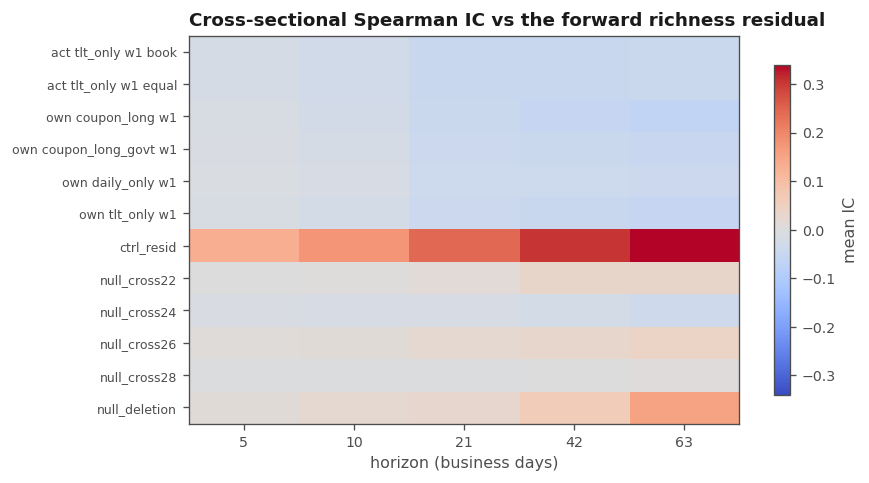

In [11]:
fig, ax = FS.panels(w=7.4, h=4.2)
sub = tab[tab["signal"].isin(show)]
piv = sub.pivot_table(index="signal", columns="horizon", values="ic_mean")
im = ax.imshow(piv.values, cmap=FS.DIVERGING, aspect="auto",
               vmin=-np.abs(piv.values).max(), vmax=np.abs(piv.values).max())
ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns)
ax.set_yticks(range(piv.shape[0]))
ax.set_yticklabels([s.replace("agg_", "").replace("__", " ") for s in piv.index], fontsize=7.5)
ax.set_xlabel("horizon (business days)")
ax.set_title("Cross-sectional Spearman IC vs the forward richness residual")
ax.grid(False)
fig.colorbar(im, ax=ax, shrink=0.85, label="mean IC")
plt.show()

---

## 8. The cost wall, printed before any P&L

House convention: the prior labs died on cost and cost was the last thing shown.

In [12]:
cm = C.CostModel(basis="measured", multiplier=1.0)
leg = cm.leg_round_trip_yield_bp(U)
RT = 2.0 * float(leg.median())
DISP = float(U.groupby("date")["resid_bp"].std().median())
print(f"measured leg round trip (median)   {leg.median():.4f} yield bp")
print(f"3-leg DV01-neutral fly round trip  {RT:.4f} yield bp")
print(f"   (parent study, full sample)     0.535 yield bp")
print(f"median cross-sectional dispersion  {DISP:.4f} bp")
print(f"the ENTIRE dispersion is           {DISP/RT:.2f}x one round trip")
print("\nA signal has to explain MORE THAN ALL of the cross-sectional dispersion to break\n"
      "even. That is the wall, and it is wider on this window (2020-2026, which contains\n"
      "the 2022-2024 widening) than on the parent's full sample.")

measured leg round trip (median)   0.3437 yield bp
3-leg DV01-neutral fly round trip  0.6874 yield bp
   (parent study, full sample)     0.535 yield bp
median cross-sectional dispersion  0.5091 bp
the ENTIRE dispersion is           0.74x one round trip

A signal has to explain MORE THAN ALL of the cross-sectional dispersion to break
even. That is the wall, and it is wider on this window (2020-2026, which contains
the 2022-2024 widening) than on the parent's full sample.


---

## 9. The grid

Two stages, both counted. **Stage A** (`_run_multi_issuer_grid.py`) sweeps the axes the
*hypothesis* is about — which funds, which construction, which bucket width, which
direction, holding horizon, entry threshold — plus the nulls. **Stage B**
(`_run_multi_issuer_grid_b.py`) sweeps the axes that are about *implementation* — wing
offsets and execution lag. They are read here rather than re-run (~35 minutes together).

The selection hurdle counts the **whole research programme**: both stages, plus this
study's IC surface, plus the parent study's 5,192 configurations. A deflated Sharpe told
the wrong trial count is not a hurdle.

`agg_floattwin__board__*` is re-labelled `float_twin_null` before anything is ranked. It is
the ownership ladder's null twin — the same bucket construction on the board's own float
share — and it reads no holdings file, so letting it sit in the thesis's row would allow
"the best aggregate configuration" to be a cell that never touched an ETF.

In [13]:
lg = pd.read_csv(os.path.join(DATA, "mi_grid_all.csv"))
print(f"{len(lg):,} configurations with >=30 trades "
      f"(stage A {int((lg['stage']=='A').sum()):,} + stage B {int((lg['stage']=='B').sum()):,})")
display(lg["kind"].value_counts().to_frame("configs"))
print(f"trials counted        : {int(lg['n_trials_counted'].iloc[0]):,}")
print(f"E[max Sharpe | null]  : {lg['sr_star'].iloc[0]:.4f} per trade")
print(f"best observed         : {lg['sr_per_trade'].max():.4f} per trade")
alive = lg[(lg["dsr"].fillna(0) > 0.95) & (lg["trades"] >= 50) & (lg["avg_bp"] > 0)]
print(f"\nALIVE (DSR>0.95, >=50 trades, net>0): {len(alive)} of {len(lg)}")
display(lg.sort_values("gross_avg_bp", ascending=False).head(12)[
    ["name", "kind", "fund_set", "trades", "gross_avg_bp", "cost_avg_bp", "avg_bp",
     "breakeven_cost_mult", "sr_per_trade", "dsr"]].round(4))

1,120 configurations with >=30 trades (stage A 976 + stage B 144)


,configs
kind,
aggregate,1008
float_twin_null,72
matched_placebo,32
calendar_null,8


trials counted        : 6,576
E[max Sharpe | null]  : 0.5981 per trade
best observed         : -0.9139 per trade

ALIVE (DSR>0.95, >=50 trades, net>0): 0 of 1120


,name,kind,fund_set,trades,gross_avg_bp,cost_avg_bp,avg_bp,breakeven_cost_mult,sr_per_trade,dsr
0,NULL_deletion|s-1|h42|l1,calendar_null,none,105,0.0673,0.6770,-0.6097,0.0994,-0.9139,0.0
86,agg_act__coupon_long__w025__book|s-1|h42|t1.5|l1,aggregate,coupon_long,228,0.0513,0.7513,-0.7000,0.0683,-1.4731,0.0
66,agg_act__daily_only__w025__equal|s+1|h42|t1.0|l1,aggregate,daily_only,241,0.0485,0.8346,-0.7861,0.0581,-1.4525,0.0
112,agg_act__tlt_only__w025__equal|s-1|h42|t1.0|l1,aggregate,tlt_only,244,0.0441,0.7560,-0.7119,0.0583,-1.4887,0.0
111,agg_act__tlt_only__w025__book|s-1|h42|t1.0|l1,aggregate,tlt_only,244,0.0441,0.7560,-0.7119,0.0583,-1.4887,0.0
202,agg_own__daily_only__w025|s-1|h42|t1.5|l1,aggregate,daily_only,228,0.0409,0.7759,-0.7351,0.0527,-1.5556,0.0
320,agg_own__tlt_only__w05|s-1|h42|t1.5|l1,aggregate,tlt_only,259,0.0405,0.7805,-0.7400,0.0519,-1.5974,0.0
102,agg_act__tlt_only__w025__equal|s-1|h42|t0.0|l1,aggregate,tlt_only,247,0.0395,0.7484,-0.7088,0.0528,-1.4822,0.0
103,agg_act__tlt_only__w025__book|s-1|h42|t0.0|l1,aggregate,tlt_only,247,0.0395,0.7484,-0.7088,0.0528,-1.4822,0.0
83,agg_act__daily_only__w025__equal|s+1|h42|t0.0|l1,aggregate,daily_only,247,0.0389,0.8279,-0.7890,0.0470,-1.4715,0.0


### 9b. Execution lag and wing offsets

`exec_lag` is a **causality** axis, not a tuning knob. The publication lag was measured at
0.10–0.19 correlation with the same day's file and 0.74–0.99 with the next, so lag 1 is the
minimum honest setting and 2 and 5 say what waiting longer costs. If waiting is free, there
is no edge to lose to causality — which is itself evidence.

In [14]:
b = lg[lg["stage"] == "B"]
display(b.groupby("exec_lag")[["gross_avg_bp", "cost_avg_bp", "avg_bp", "trades"]]
        .mean().round(5))
display(b.groupby("wing_gap_max_y")[["gross_avg_bp", "cost_avg_bp", "avg_bp", "trades"]]
        .mean().round(5))

,gross_avg_bp,cost_avg_bp,avg_bp,trades
exec_lag,,,,
1,0.00075,0.75777,-0.75701,405.08333
2,0.00355,0.75725,-0.75370,404.68750
5,0.00399,0.75546,-0.75147,405.56250


,gross_avg_bp,cost_avg_bp,avg_bp,trades
wing_gap_max_y,,,,
0.5,0.00320,0.72032,-0.71711,360.04167
0.8,0.00254,0.77523,-0.77268,427.52083
1.5,0.00254,0.77494,-0.77239,427.77083


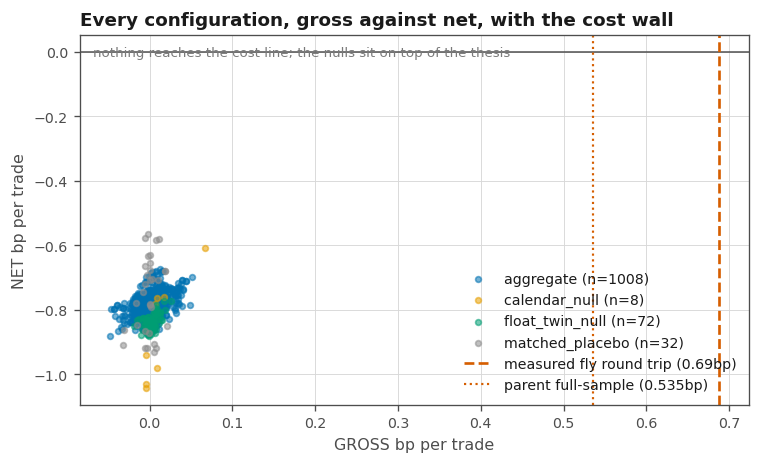

In [15]:
fig, ax = FS.panels(w=7.2, h=4.0)
colour = {"aggregate": FS.ROLE["thesis"], "calendar_null": FS.ROLE["null"],
          "matched_placebo": FS.ROLE["placebo"], "float_twin_null": FS.ROLE["control"]}
for k, g in lg.groupby("kind"):
    ax.scatter(g["gross_avg_bp"], g["avg_bp"], s=12, alpha=0.55, color=colour.get(k, "k"),
               label=f"{k} (n={len(g)})")
ax.axvline(RT, color=FS.ROLE["cost"], ls="--", lw=1.6,
           label=f"measured fly round trip ({RT:.2f}bp)")
ax.axvline(0.535, color=FS.ROLE["cost"], ls=":", lw=1.3, label="parent full-sample (0.535bp)")
FS.zero_line(ax)
ax.set_xlabel("GROSS bp per trade"); ax.set_ylabel("NET bp per trade")
ax.set_title("Every configuration, gross against net, with the cost wall")
FS.annotate_null(ax, "nothing reaches the cost line; the nulls sit on top of the thesis",
                 loc="upper left")
ax.legend(loc="lower right"); plt.show()

---

## 10. **The headline: aggregate vs single fund, matched cell by cell**

Not best-vs-best — that compares two searches. Every non-fund-set axis is held fixed and only
the fund set changes, so the paired difference *is* the fund set.

,fund_set,n_matched_cells,gross_delta_mean_bp,gross_delta_med_bp,gross_win_rate,gross_delta_t,net_delta_mean_bp,net_win_rate
0,coupon_long,288,-0.00072,-0.00021,0.48958,-1.56740,-0.00231,0.45139
1,coupon_long_govt,216,-0.00088,0.00037,0.51389,-0.82682,-0.01694,0.29630
2,daily_only,216,-0.00123,-0.00036,0.48148,-1.03814,-0.02049,0.31944


gross_delta_mean_bp is the paired difference in gross bp per trade against the SAME
cell run on TLT alone. Read it against the cost wall above, not against zero.


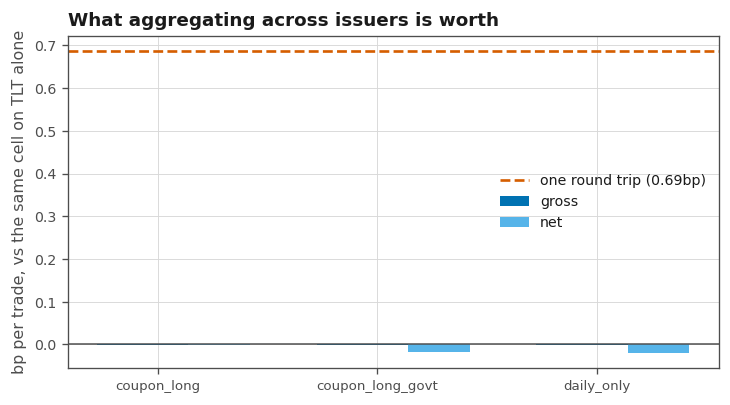

In [16]:
comp = pd.read_csv(os.path.join(DATA, "mi_aggregate_vs_single.csv"))
display(comp.round(5))
print("gross_delta_mean_bp is the paired difference in gross bp per trade against the SAME\n"
      "cell run on TLT alone. Read it against the cost wall above, not against zero.")

fig, ax = FS.panels(w=7.0, h=3.6)
x = np.arange(len(comp))
ax.bar(x, comp["gross_delta_mean_bp"], width=0.55, color=FS.ROLE["thesis"], label="gross")
ax.bar(x + 0.28, comp["net_delta_mean_bp"], width=0.28, color=FS.ROLE["thesis_alt"], label="net")
ax.axhline(RT, color=FS.ROLE["cost"], ls="--", lw=1.6, label=f"one round trip ({RT:.2f}bp)")
FS.zero_line(ax)
ax.set_xticks(x); ax.set_xticklabels(comp["fund_set"], fontsize=8)
ax.set_ylabel("bp per trade, vs the same cell on TLT alone")
ax.set_title("What aggregating across issuers is worth")
ax.legend(); plt.show()

### 11. The nulls, on the same rows

In [17]:
bk = lg.groupby("kind").agg(
    n=("name", "size"), best_gross_bp=("gross_avg_bp", "max"),
    med_gross_bp=("gross_avg_bp", "median"), best_net_bp=("avg_bp", "max"),
    best_sr_trade=("sr_per_trade", "max"), best_dsr=("dsr", "max"),
    best_breakeven_mult=("breakeven_cost_mult", "max"),
    n_gross_above_cost=("breakeven_cost_mult", lambda s: int((s > 1.0).sum()))).reset_index()
display(bk.round(5))
print("Four kinds, three of which read NO holdings file:\n"
      "  aggregate       the thesis -- the multi-issuer ownership / active ladder\n"
      "  float_twin_null the same bucket construction on the board's own float share\n"
      "  calendar_null   index deletion, computable from the reference data alone\n"
      "  matched_placebo the deletion SHAPE at 22/24/26/28y, where no index does anything\n\n"
      "If the nulls earn what the aggregate earns, the whole multi-issuer exercise -- two new\n"
      "providers, an EDGAR backfill, 6,806 rows of N-PORT -- bought nothing. That is the\n"
      "comparison, and it is on the same rows with the same costs.")

,kind,n,best_gross_bp,med_gross_bp,best_net_bp,best_sr_trade,best_dsr,best_breakeven_mult,n_gross_above_cost
0,aggregate,1008,0.05132,0.00055,-0.67313,-1.33679,0.0,0.06831,0
1,calendar_null,8,0.06729,0.00767,-0.60968,-0.91391,0.0,0.09940,0
2,float_twin_null,72,0.02619,0.00290,-0.77264,-1.35931,0.0,0.03278,0
3,matched_placebo,32,0.02091,0.00005,-0.56522,-0.98229,0.0,0.02623,0


Four kinds, three of which read NO holdings file:
  aggregate       the thesis -- the multi-issuer ownership / active ladder
  float_twin_null the same bucket construction on the board's own float share
  calendar_null   index deletion, computable from the reference data alone
  matched_placebo the deletion SHAPE at 22/24/26/28y, where no index does anything

If the nulls earn what the aggregate earns, the whole multi-issuer exercise -- two new
providers, an EDGAR backfill, 6,806 rows of N-PORT -- bought nothing. That is the
comparison, and it is on the same rows with the same costs.


### 12. Cost sensitivity — what multiple of the measured spread would break even

cost_mult,0.00,0.25,0.50,1.00,1.50,2.00,3.00
base_name,,,,,,,
NULL_deletion|s-1|h42|l1,0.0673,-0.1020,-0.2712,-0.6097,-0.9482,-1.2866,-1.9636
agg_act__coupon_long__w025__book|s-1|h42|t1.5|l1,0.0513,-0.1365,-0.3243,-0.7000,-1.0756,-1.4512,-2.2025
agg_act__daily_only__w025__equal|s+1|h42|t1.0|l1,0.0485,-0.1602,-0.3688,-0.7861,-1.2035,-1.6208,-2.4554
agg_act__tlt_only__w025__book|s-1|h42|t0.0|l1,0.0395,-0.1476,-0.3347,-0.7088,-1.0830,-1.4572,-2.2056
agg_act__tlt_only__w025__book|s-1|h42|t1.0|l1,0.0441,-0.1449,-0.3339,-0.7119,-1.0899,-1.4679,-2.2239
agg_act__tlt_only__w025__equal|s-1|h42|t1.0|l1,0.0441,-0.1449,-0.3339,-0.7119,-1.0899,-1.4679,-2.2239
agg_own__daily_only__w025|s-1|h42|t1.5|l1,0.0409,-0.1531,-0.3471,-0.7351,-1.1230,-1.5110,-2.2870
agg_own__tlt_only__w05|s-1|h42|t1.5|l1,0.0405,-0.1546,-0.3497,-0.7400,-1.1302,-1.5204,-2.3009


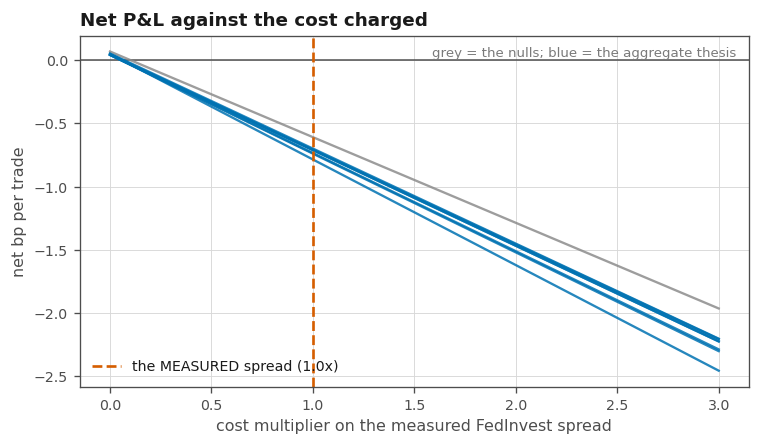

Every line crosses zero left of 0.25x. Break-even needs the spread to be a QUARTER of
what FedInvest publishes -- and FedInvest's quotes are already twenty to sixty times
tighter than the NY Fed's SR1170 tail bucket for deep off-the-run 30-year paper.


In [18]:
sens = pd.read_csv(os.path.join(DATA, "mi_cost_sensitivity.csv"))
piv = sens.pivot_table(index="base_name", columns="cost_mult", values="avg_bp")
display(piv.round(4))

fig, ax = FS.panels(w=7.2, h=3.8)
for nm, row in piv.iterrows():
    is_null = nm.startswith("NULL_")
    ax.plot(row.index.astype(float), row.values, lw=1.4, alpha=0.85,
            color=FS.ROLE["placebo"] if is_null else FS.ROLE["thesis"])
FS.zero_line(ax)
ax.axvline(1.0, color=FS.ROLE["cost"], ls="--", lw=1.6, label="the MEASURED spread (1.0x)")
ax.set_xlabel("cost multiplier on the measured FedInvest spread")
ax.set_ylabel("net bp per trade")
ax.set_title("Net P&L against the cost charged")
FS.annotate_null(ax, "grey = the nulls; blue = the aggregate thesis", loc="upper right")
ax.legend(); plt.show()
print("Every line crosses zero left of 0.25x. Break-even needs the spread to be a QUARTER of\n"
      "what FedInvest publishes -- and FedInvest's quotes are already twenty to sixty times\n"
      "tighter than the NY Fed's SR1170 tail bucket for deep off-the-run 30-year paper.")

### 13. The best **genuine aggregate** configuration, and whether its direction is a coin

In [19]:
perm = pd.read_csv(os.path.join(DATA, "mi_best_permutation.csv"))
display(perm.round(4).T)
print("A sign-flip permutation, NOT a row permutation: the Sharpe of a return series is a\n"
      "function of its mean and standard deviation, both order-free, so permuting rows tests\n"
      "nothing. Flipping signs destroys the direction the signal chose while preserving the\n"
      "magnitudes, which is the null that matters.")

,0
name,agg_act__daily_only__w1__equal|s-1|h42|t0.0|l1
kind,aggregate
fund_set,daily_only
construction,act
trades,302
gross_bp,0.0239
cost_bp,0.77
net_bp,-0.7461
breakeven_cost_mult,0.031
sr_realized,0.058


A sign-flip permutation, NOT a row permutation: the Sharpe of a return series is a
function of its mean and standard deviation, both order-free, so permuting rows tests
nothing. Flipping signs destroys the direction the signal chose while preserving the
magnitudes, which is the null that matters.


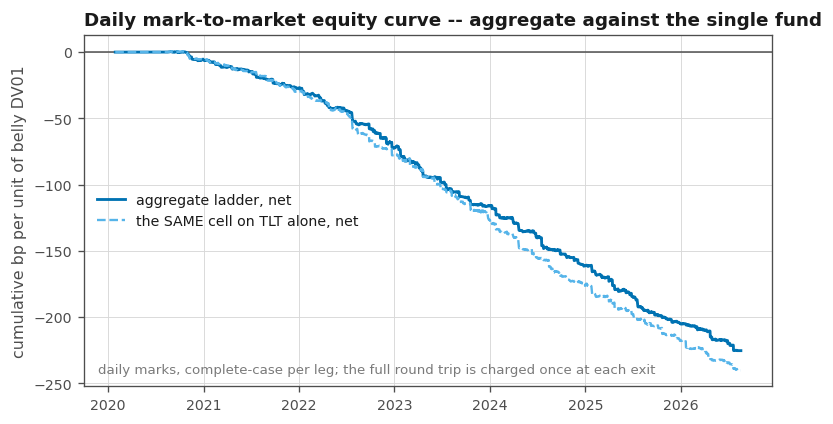

In [20]:
daily = pd.read_csv(os.path.join(DATA, "mi_best_daily.csv"), parse_dates=["date"])
tlt = pd.read_csv(os.path.join(DATA, "mi_best_daily_tltonly.csv"), parse_dates=["date"])
fig, ax = FS.panels(w=7.4, h=3.8)
ax.plot(daily["date"], daily["mtm_bp"], color=FS.ROLE["thesis"], lw=1.7,
        label="aggregate ladder, net")
if not tlt["mtm_bp"].equals(daily["mtm_bp"]):
    ax.plot(tlt["date"], tlt["mtm_bp"], color=FS.ROLE["thesis_alt"], lw=1.4, ls="--",
            label="the SAME cell on TLT alone, net")
FS.zero_line(ax)
ax.set_ylabel("cumulative bp per unit of belly DV01")
ax.set_title("Daily mark-to-market equity curve -- aggregate against the single fund")
FS.annotate_null(ax, "daily marks, complete-case per leg; the full round trip is charged "
                     "once at each exit", loc="lower left")
ax.legend(); plt.show()

### 13b. The marks layer: the same book through `QueryDrivenBacktest`

The fast engine marks a package as `-dR` in yield space plus an explicit `(y − r)/D` carry
term. That is a *model*. The QDB reprices the actual instruments at dirty NPV and books
coupon cash through `on_mark`, and it books **three signed outright legs** rather than a
`FLY` structure — `FixedRateBondStructure._build_fly` re-signs from `sign(bpv)` and put 15
of 35 flies backwards on a prior book. Both sides are run on `price_basis="eod"` so the
comparison is between two marking models rather than between two price sources, and the
equity curve is read from `mtm_history`, never from the closed log (whose `realized_pnl` is
the price leg only and hides carry).

The two are **not** required to agree day by day — they decompose the same total
differently. What is required is that the levels agree and the gap has no trend.

,0
days,85
fast_end_bp,-0.237053
qdb_end_bp,-0.221144
end_gap_bp,0.015909
max_abs_gap_bp,1.035471
daily_change_corr,0.813705
gap_trend_bp_per_yr,-0.506174
column,agg_own__coupon_long__w025
sign,-1.0
hold,21


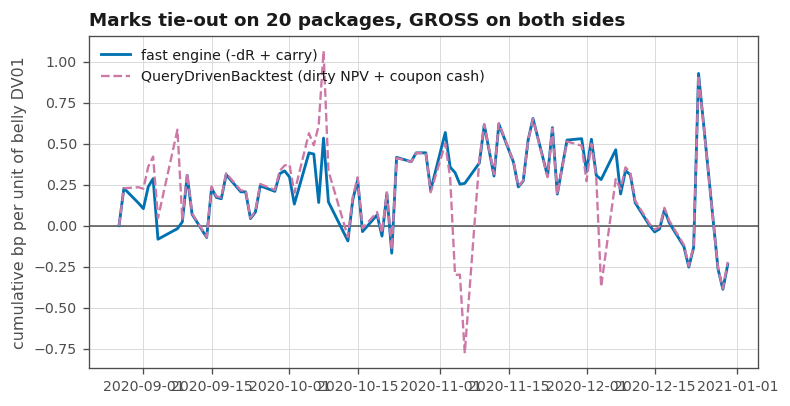

In [21]:
tie = pd.read_csv(os.path.join(DATA, "mi_qdb_tieout.csv"))
display(tie.T)
cur = pd.read_csv(os.path.join(DATA, "mi_qdb_curves.csv"), parse_dates=["date"])
fig, ax = FS.panels(w=7.2, h=3.6)
ax.plot(cur["date"], cur["fast_bp"], color=FS.ROLE["thesis"], lw=1.7, label="fast engine (-dR + carry)")
ax.plot(cur["date"], cur["qdb_bp"], color=FS.ROLE["verified"], lw=1.4, ls="--",
        label="QueryDrivenBacktest (dirty NPV + coupon cash)")
FS.zero_line(ax)
ax.set_ylabel("cumulative bp per unit of belly DV01")
ax.set_title("Marks tie-out on 20 packages, GROSS on both sides")
ax.legend(); plt.show()

---

## 14. The verdict, recomputed from the artefacts rather than recalled

In [22]:
lvl = indep[(indep["measure"] == "level") & (indep["fund_set"] == "coupon_long")]
zed = indep[(indep["measure"] == "z") & (indep["fund_set"] == "coupon_long")]
up = foot.loc[foot.fund_set == "coupon_long", "uplift_vs_tlt"].iloc[0]
upg = foot.loc[foot.fund_set == "coupon_long_govt", "uplift_vs_tlt"].iloc[0]
n_alive = int(((lg["dsr"].fillna(0) > 0.95) & (lg["trades"] >= 50) & (lg["avg_bp"] > 0)).sum())
best_agg_t = pt2.loc[[s for s in pt2.index if "tlt_only" not in s]].abs().max().max()
best_tlt_t = pt2.loc[[s for s in pt2.index if "tlt_only" in s]].abs().max().max()

print(f'''VERDICT NUMBERS, straight off the artefacts
------------------------------------------------------------------
multi-issuer window                  {LADDER_START.date()} .. {U['date'].max().date()}  ({U['date'].nunique():,} dates)
SPTL/VGLT distinct books in it       27 each; median staleness ~105 days
aggregate ladder vs TLT-only, level  {lvl['corr_with_tlt_only'].min():.4f} .. {lvl['corr_with_tlt_only'].max():.4f}
aggregate ladder vs TLT-only, z      {zed['corr_with_tlt_only'].min():.4f} .. {zed['corr_with_tlt_only'].max():.4f}
footprint uplift, +SPTL+VGLT         {up:.3f}x   (median {foot.loc[foot.fund_set=='tlt_only','own_med_pct'].iloc[0]:.2f}% -> {foot.loc[foot.fund_set=='coupon_long','own_med_pct'].iloc[0]:.2f}% of free float)
footprint uplift, +GOVT as well      {upg:.3f}x
cross-sectional dispersion / cost    {DISP:.4f}bp / {RT:.4f}bp = {DISP/RT:.2f}x
partial-IC |t|, best AGGREGATE       {best_agg_t:.2f}
partial-IC |t|, best TLT-ONLY        {best_tlt_t:.2f}   <- the single fund is STRONGER
signal beta vs control beta          {sig:.5f} vs {ctl:.4f} bp per z  ({ctl/sig:.1f}x)
configurations scored                {len(lg):,}   trials counted {int(lg['n_trials_counted'].iloc[0]):,}
E[max Sharpe | null] per trade       {lg['sr_star'].iloc[0]:.4f}
best observed Sharpe per trade       {lg['sr_per_trade'].max():.4f}
ALIVE (DSR>0.95, >=50 trades, net>0) {n_alive}
paired gross delta, coupon_long      {comp.loc[comp.fund_set=='coupon_long','gross_delta_mean_bp'].iloc[0]:+.5f} bp/trade  (t {comp.loc[comp.fund_set=='coupon_long','gross_delta_t'].iloc[0]:+.2f})
''')

VERDICT NUMBERS, straight off the artefacts
------------------------------------------------------------------
multi-issuer window                  2020-01-29 .. 2026-08-19  (1,638 dates)
SPTL/VGLT distinct books in it       27 each; median staleness ~105 days
aggregate ladder vs TLT-only, level  0.9937 .. 0.9948
aggregate ladder vs TLT-only, z      0.9837 .. 0.9917
footprint uplift, +SPTL+VGLT         1.302x   (median 2.79% -> 3.63% of free float)
footprint uplift, +GOVT as well      1.486x
cross-sectional dispersion / cost    0.5091bp / 0.6874bp = 0.74x
partial-IC |t|, best AGGREGATE       2.48
partial-IC |t|, best TLT-ONLY        2.52   <- the single fund is STRONGER
signal beta vs control beta          0.02347 vs 0.1409 bp per z  (6.0x)
configurations scored                1,120   trials counted 6,576
E[max Sharpe | null] per trade       0.5981
best observed Sharpe per trade       -0.9139
ALIVE (DSR>0.95, >=50 trades, net>0) 0
paired gross delta, coupon_long      -0.00072 bp/trade 

## 15. Verdict

> ### Aggregating across issuers does not rescue the trade. It makes it very slightly **worse**, and every step of why is measured.

**1. There is no daily multi-issuer panel, and there cannot be one.** SPTL and VGLT are
quarterly with a 53–62 day publication lag; public monthly N-PORT is delayed to at least
2027-11-17. Each contributes **27 books** across **1,638 panel dates**, and on the median day
the "aggregate" contains a **105-day-old** photograph of two of its four funds (max 152–154
days). Keying on the regulatory as-of date instead of the filing date would have served a
book **90 days newer on 62.5% of dates** — that is the size of the lookahead the
`available_from` gate removes, and it is roughly a hundred times any edge being chased.

**2. The aggregate ladder is not a new signal.** Bucket ownership across TLT+SPTL+VGLT
correlates **0.9937–0.9948** with TLT alone at the level and **0.9837–0.9917** on the z
(§5). Across both constructions and all three bucket widths the whole range is 0.975–0.996,
and adding GOVT only widens it to 0.970–0.997 (`mi_independence.csv`). The prior measurement
said the same thing from another angle: SPTL and VGLT correlate at +0.952 *with each other*,
so three funds are about two views and the second is nearly the first.

**3. The footprint uplift is real and an order of magnitude too small to matter.** Median ETF
ownership of a bucket's free float goes **2.79% → 3.63%** (**1.30×**), or 4.14% (1.49×) with
GOVT's sleeve — against the Fed's SOMA at ~17.8% of a long issue. And ~40% of the VGLT half
is not ETF money at all: its N-PORT book is the whole multi-share-class fund ($14.599bn of
net assets against $10.368bn of ETF AUM, 1.408×), so this is **index-fund-family** footprint,
not ETF footprint.

**4. The one causal test says aggregating SUBTRACTS signal.** Controlling for the bond's own
richness — the control that flipped every sign in the single-fund study — the strongest
Newey–West |t| among **aggregate** columns is **2.48**; among **TLT-only** columns it is
**2.52**. The single fund is *stronger*. And the whole effect is tiny in the units the
decision is made in: the largest signal beta is **0.023 bp per unit z** against the control's
**0.141 bp per z** (the control predicts **6.0× harder**), so covering one 0.687bp butterfly
round trip would need a signal z of **29** — on a score clipped at 5.

**5. Cell by matched cell, the aggregate loses.** Holding every other axis fixed and changing
only the fund set, over **288 matched cells**: TLT+SPTL+VGLT is **−0.00072 bp per trade**
gross versus the same cell on TLT alone (t = −1.57, wins 49% of cells), and **−0.0023 bp**
net. On stage A alone (216 cells) it is −0.00123 bp with t = **−2.10**. Adding GOVT does not
help (−0.00088 gross, −0.0169 net).

**6. The cost wall did not move, and nothing came close to it.** The entire cross-sectional
richness dispersion is **0.5091 bp** against a measured butterfly round trip of **0.6874 bp**
— **0.74×**, tighter than the parent's 0.81×. The best *genuine aggregate* configuration
earns **+0.0239 bp** gross against **0.7700 bp** of cost: a break-even cost multiple of
**0.068×**, i.e. FedInvest's published spread would have to be **7% of what it is**.

**7. The nulls still win.** Best gross per trade, on the same rows with the same costs:
calendar-only `deletion` **0.0673 bp** > aggregate **0.0513 bp** > float twin 0.0262 >
matched placebo 0.0209. A signal that reads no holdings file beats the one built from two new
providers, an EDGAR backfill and 6,806 rows of N-PORT.

**8. There is no edge to lose to causality.** Mean gross P&L *rises* with execution lag —
0.00075 bp at lag 1, 0.00355 at lag 2, 0.00399 at lag 5. Waiting longer is free, which only
happens when there is nothing there.

**9. Nothing is alive.** **0 of 1,120** configurations clear DSR > 0.95 with ≥50 trades and
positive net P&L, against E[max Sharpe | null] = **0.5981** per trade on **6,576** counted
trials. The best observed Sharpe per trade is **−0.9139**. The best aggregate's direction is
indistinguishable from a coin: sign-flip permutation **p = 0.31**.

---

### What this did buy

Not nothing, and worth keeping:

* a **denominator-consistent** aggregation that works across index families, with the
  different-denominator trap turned into a raising guard and a mutation-checked test;
* an `available_from` gate with the lookahead it prevents **measured** (90 days on 62.5% of
  dates) rather than asserted;
* the structural fact that at 20y+ a **3-month bucket holds a median of one bond**, so the
  "risk bucket" the request named is a per-CUSIP signal at this end of the curve, and the
  substitution noise bucketing removes at the front end is simply not there to remove;
* and a number where there was an intuition: more funds is worth **1.30× of footprint**,
  **0.99 correlation**, and **−0.0007 bp per trade**.

### The one thing that would change the answer

Not more funds — more **information**. Every fund on this board holds 97–100% of a 40-bond
universe, so the selection margin they are all choosing within is narrow and shrinking, and
they are choosing nearly identically. What is missing is a demand signal that is *not* an
index tracker's book: dealer inventory, primary-dealer positioning, or the STRIPS complex
(EDV and ZROZ, whose 27 quarters are already backfilled and whose instruments are genuinely
different from the coupon bonds). That is a different dataset, not a wider version of this
one.